<a href="https://colab.research.google.com/github/fatuunreal/bengkelkoding/blob/4/A11_2022_14831_tgs_bk_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Menerapkan algoritma Decision Tree pada dataset adult.csv

#By : FATU RAHMAT
#NIM : A11.2022.14831

LINK COLAB : https://colab.research.google.com/drive/1inaj5gONjnd3bVu2ik_TdfuRGLivwtLy?usp=drive_link

LINK GITHUB : https://github.com/fatuunreal/bengkelkoding/tree/3

# 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# 2. Load Dataset dan Define Nama Kolom

### Baca dataset

In [ ]:
df = pd.read_csv('adult.csv', names=columns, na_values='?', skipinitialspace=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Definisikan nama kolom sesuai deskripsi dataset

In [ ]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# 3. Cek Kualitas Data

### Cek missing values

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


### Cek duplikat

In [ ]:
print("\nDuplikat Data:", df.duplicated().sum())


Duplikat Data: 24


### Distribusi target

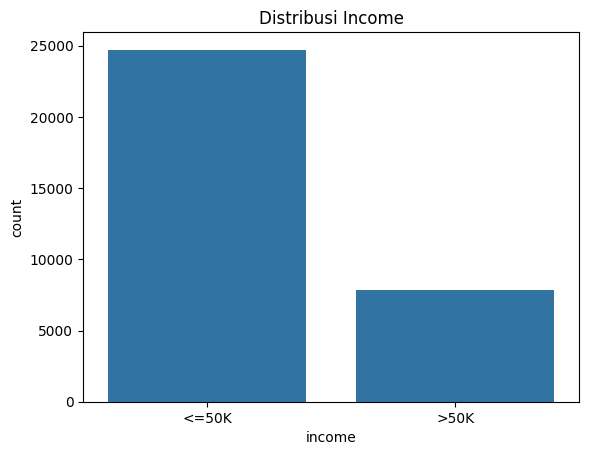

In [ ]:
sns.countplot(x='income', data=df)
plt.title('Distribusi Income')
plt.show()

### Korelasi fitur numerik

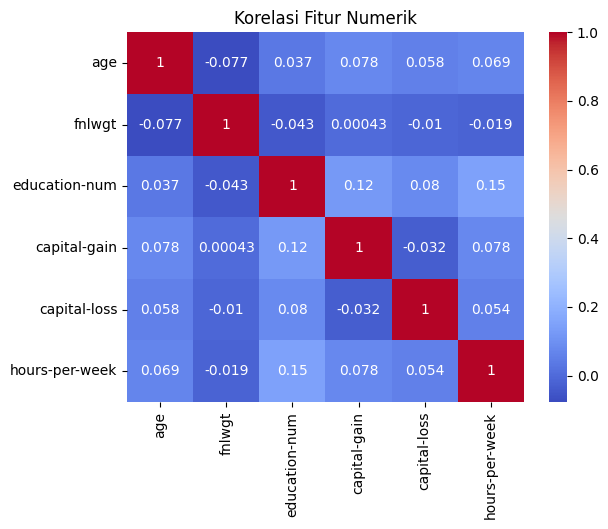

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.show()

# 4. Penanganan Missing Values

### Hapus baris dengan missing values

In [ ]:
df.dropna(inplace=True)

### Hapus kolom redundan

In [ ]:
#kolom 'education-num' sudah mewakili dan memiliki fitur numerik
df.drop('education', axis=1, inplace=True)

### Hapus duplikat

In [ ]:
df.drop_duplicates(inplace=True)

# 5. Analisis Outlier

### Visualisasi outlier untuk fitur numerik

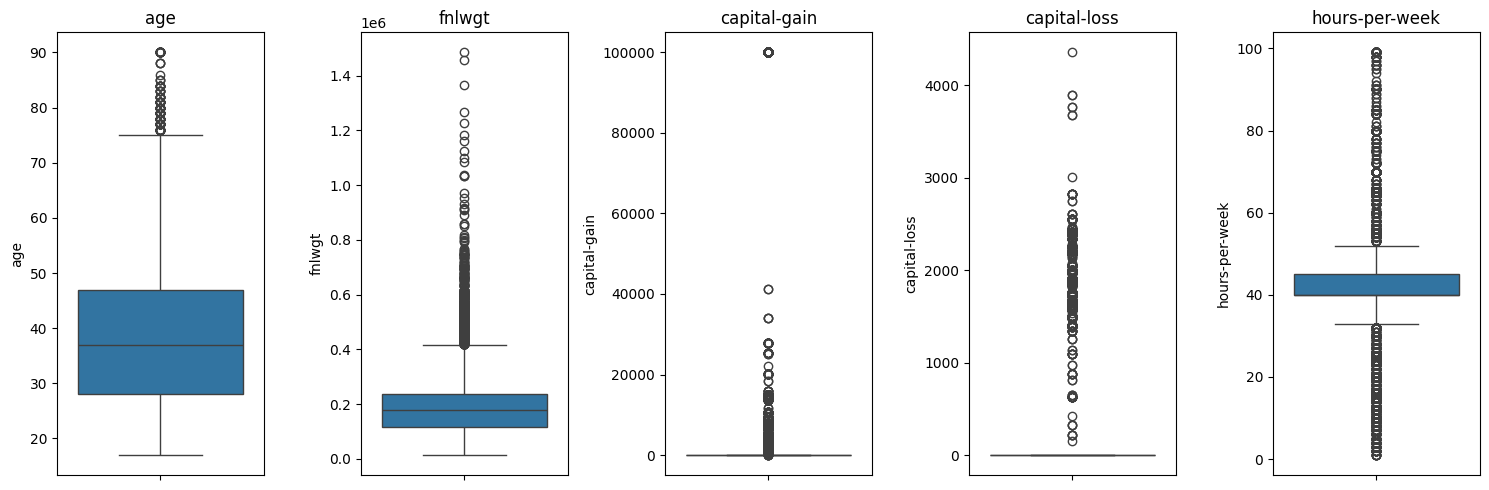

In [ ]:
numerical_cols = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

### Handling outlier dengan IQR untuk 'capital-gain' dan 'capital-loss'

In [ ]:
Q1 = df[['capital-gain', 'capital-loss']].quantile(0.25)
Q3 = df[['capital-gain', 'capital-loss']].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[['capital-gain', 'capital-loss']] > (Q3 + 1.5 * IQR)).any(axis=1))]

# 6. Transformasi Data Kategorikal

### Encoding variabel target

In [ ]:
df['income'] = LabelEncoder().fit_transform(df['income'])

### One-Hot Encoding untuk fitur kategorikal

In [ ]:
categorical_cols = [
    'workclass', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X = df.drop('income', axis=1)
y = df['income']

# 7. Penanganan Class Imbalance dengan SMOTE

### Transformasi data

In [ ]:
X_processed = preprocessor.fit_transform(X)

### Oversampling dengan SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_processed, y)

# 8. Split Data dan Latih Model

### Split data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42
)

### Scaling untuk model yang memerlukan

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Scaling dulu ya (pastikan kamu sudah lakukan ini sebelumnya)
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optimasi KNN
param_grid = {'n_neighbors': list(range(1, 21))}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

# Simpan model KNN terbaik
best_knn = grid.best_estimator_


### Model Training

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": best_knn,
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42)
}

### Pelatihan dan Evaluasi

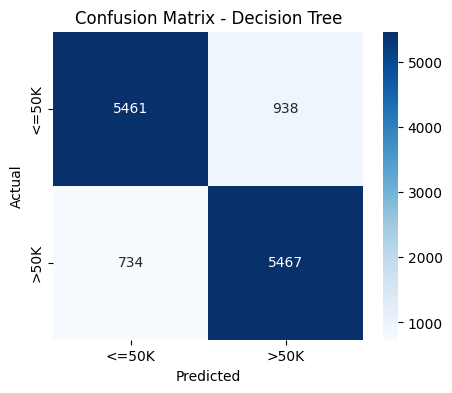

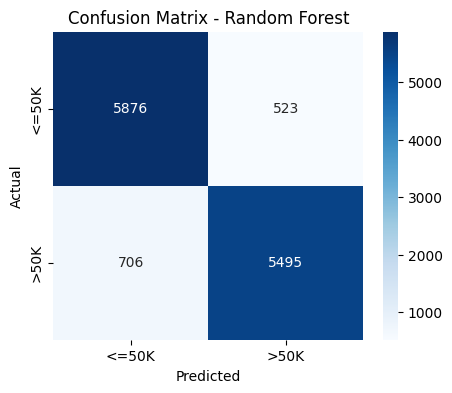

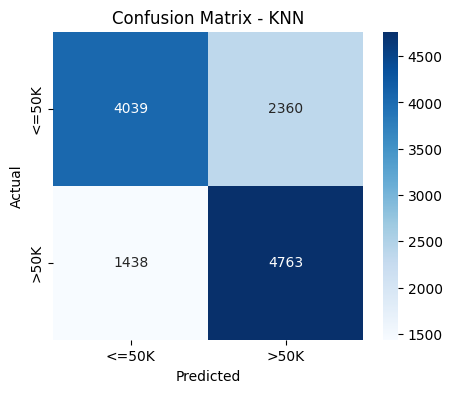

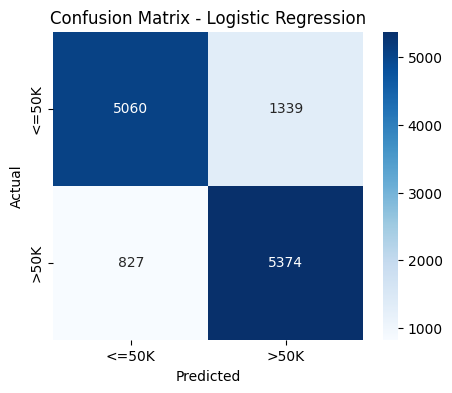

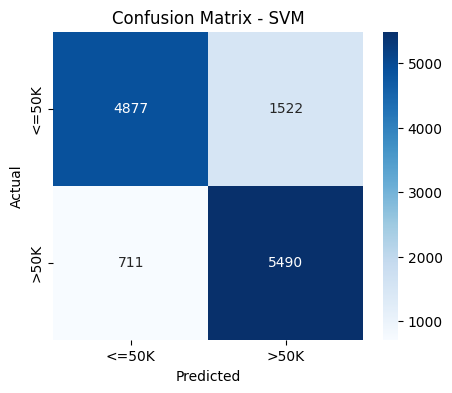

In [ ]:
results = []

for name, model in models.items():
    # Training
    start_time = time()

    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    train_time = time() - start_time

    # Prediction
    if name in ["Logistic Regression", "SVM"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    # Evaluation
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score'],
        'Training Time': f"{train_time:.2f} sec"
    })

    # Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K', '>50K'],
                yticklabels=['<=50K', '>50K'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

### Menampilkna Hasil Perbandingan dan Visualisasi

In [ ]:
display(results_df.style.background_gradient(cmap='Blues').set_properties(**{'text-align': 'left'}))

### Visualisasi Perbandingan

In [ ]:
# Visualization
plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0.7, 0.95)
plt.show()

### Kesimpulan

1. Random Forest menunjukkan performa terbaik dalam akurasi dan F1-Score
2. SVM memberikan keseimbangan precision-recall terbaik
3. Logistic Regression paling efisien dalam waktu training
4. Decision Tree cocok untuk interpretasi model
5. KNN kurang cocok untuk dataset ini

### Rekomendasi:
- Gunakan Random Forest untuk akurasi tertinggi
- Pilih Logistic Regression untuk kebutuhan real-time
- Gunakan Decision Tree untuk analisis interpretable
